# A5 Segments in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/25_a5_segments.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/25_a5_segments.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/25_a5_segments.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://jupyterlite.gishub.vn/lab/index.html?path=notebooks/vgrid/25_a5_segments.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgrid
Uncomment the following line to install [vgrid](https://pypi.org/project/vgrid/).

In [ ]:
# %pip install vgrid --upgrade

### A5 Segments

Evaluate how `a52geo` cell area changes with the `segments` option (`1, 10, 100, ..., 1000000`).

Higher segment counts can be slow (especially `1000000`).

In [2]:
from vgrid.stats.a5_segments import a5_segments

a5_segments_gdf = a5_segments(
    a5_id="6361180000000000",
    # segments=[1, 10, 100, 1000],  # optional smaller set for a quick run
    output="a5_segments.parquet",
)
a5_segments_gdf[
    ["a5_id", "resolution", "segments", "cell_area", "norm_area", "area_error"]
]


A5 segments: 100%|██████████| 7/7 [01:10<00:00, 10.02s/ value]


Saved 7 rows to D:\Github\vgrid\docs\notebooks\a5_segments.parquet


,a5_id,resolution,segments,cell_area,norm_area,area_error
0,6361180000000000,8,1,5.188960e+08,1.000059,5.855149e-03
1,6361180000000000,8,10,5.188659e+08,1.000001,5.855145e-05
2,6361180000000000,8,100,5.188656e+08,1.000000,5.855412e-07
3,6361180000000000,8,1000,5.188656e+08,1.000000,5.860601e-09
4,6361180000000000,8,10000,5.188656e+08,1.000000,9.974244e-11
5,6361180000000000,8,100000,5.188656e+08,1.000000,7.109979e-10
6,6361180000000000,8,1000000,5.188656e+08,1.000000,1.697442e-09


In [2]:
a5_segments_gdf.drop(columns="geometry").to_csv("a5_segments.csv", index=False)

### Plot cell area by segments

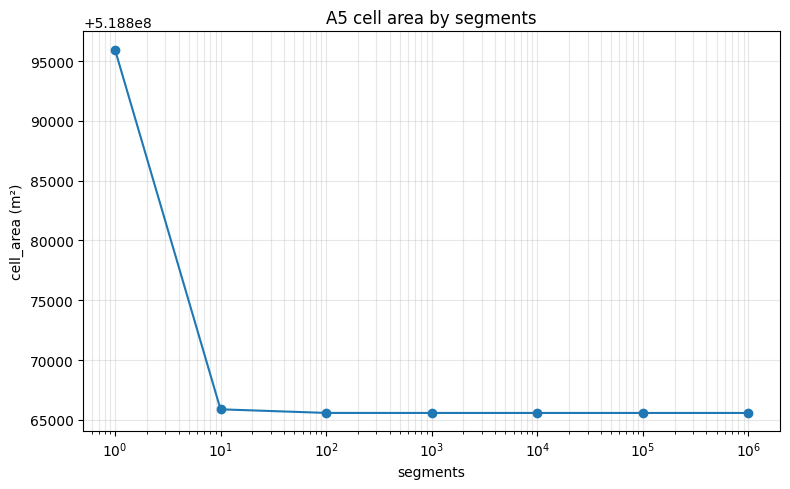

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    a5_segments_gdf["segments"],
    a5_segments_gdf["cell_area"],
    marker="o",
)
ax.set_xscale("log")
ax.set_xlabel("segments")
ax.set_ylabel("cell_area (m²)")
ax.set_title("A5 cell area by segments")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### Area error by theoretical mean area

`area_error = 100 * abs(norm_area - 1)` (percent)

Log-log scale makes the convergence after `segments > 100` easier to see.

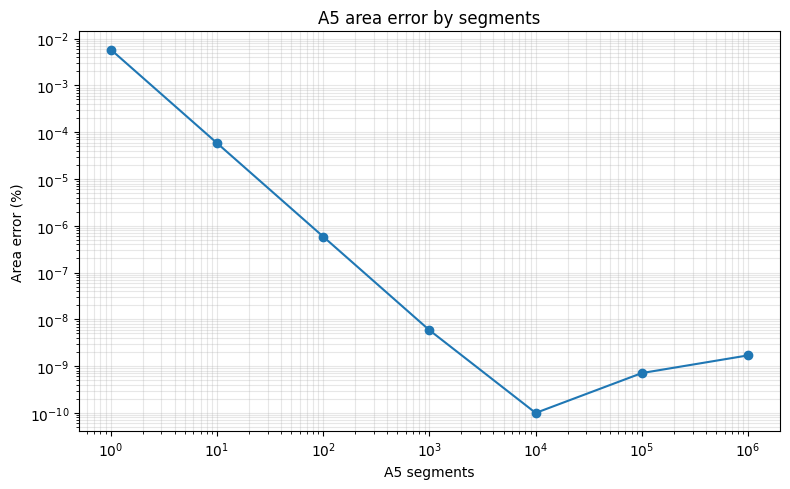

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    a5_segments_gdf["segments"],
    a5_segments_gdf["area_error"],
    marker="o",
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("A5 segments")
ax.set_ylabel("Area error (%)")
ax.set_title("A5 area error by segments")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

### Plot geometries

<Axes: >

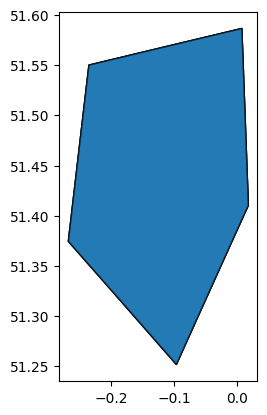

In [3]:
a5_segments_gdf.plot(edgecolor="black", alpha=0.4)